In [640]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [641]:
df = pd.read_csv("data.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [642]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [643]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [644]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [645]:
# df.columns[df.dtypes == 'str']

for column in df.columns[df.dtypes == 'str']:
    df[column] = df[column].str.lower().str.replace(' ', '_')

In [646]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Exploratory Data Analysis

In [647]:
for column in df.columns:
    print(column)
    print(df[column].unique()[:5].tolist())
    print(df[column].nunique())
    print("\n")

make
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
48


model
['1_series_m', '1_series', '100', '124_spider', '190-class']
914


year
[2011, 2012, 2013, 1992, 1993]
28


engine_fuel_type
['premium_unleaded_(required)', 'regular_unleaded', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']
10


engine_hp
[335.0, 300.0, 230.0, 320.0, 172.0]
356


engine_cylinders
[6.0, 4.0, 5.0, 8.0, 12.0]
9


transmission_type
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
5


driven_wheels
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']
4


number_of_doors
[2.0, 4.0, 3.0, nan]
3


market_category
['factory_tuner,luxury,high-performance', 'luxury,performance', 'luxury,high-performance', 'luxury', 'performance']
71


vehicle_size
['compact', 'midsize', 'large']
3


vehicle_style
['coupe', 'convertible', 'sedan', 'wagon', '4dr_hatchback']
16


highway_mpg
[26, 28, 27, 25, 24]
59


city_mpg
[19, 20, 18, 17, 16]
69


popula

**Distribution of Price**

<Axes: xlabel='msrp', ylabel='Count'>

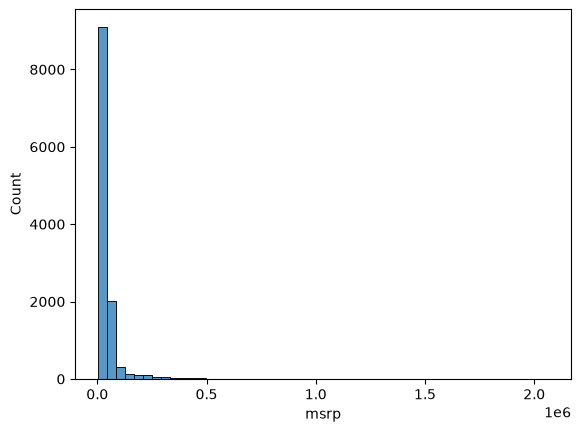

In [648]:
sns.histplot(df['msrp'], bins=50) # bins means how many bars

<Axes: >

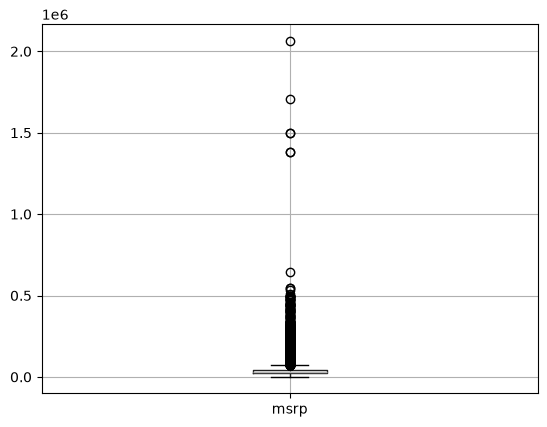

In [649]:
df.boxplot('msrp')

<Axes: xlabel='msrp', ylabel='Count'>

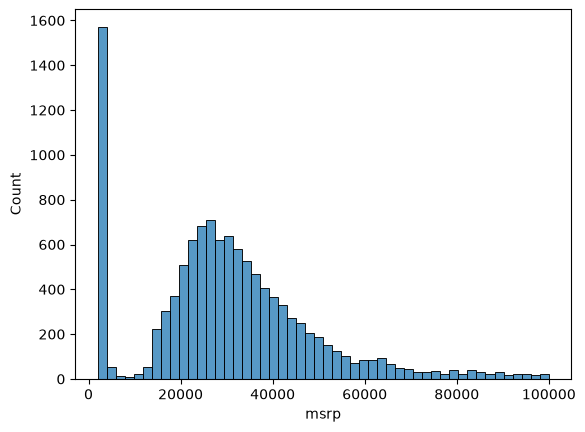

In [650]:
sns.histplot(df.msrp[df['msrp'] < 100_000], bins=50) # bins means how many bars

<Axes: xlabel='msrp', ylabel='Count'>

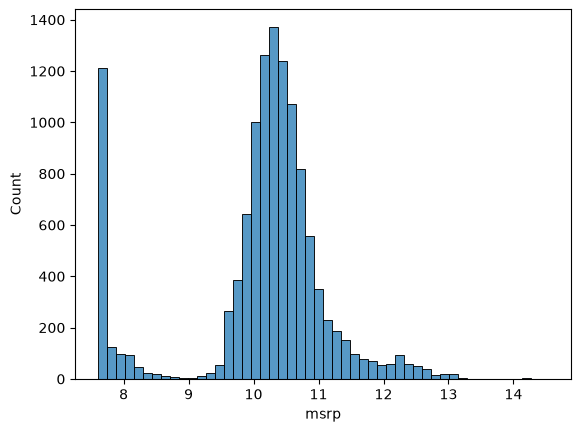

In [651]:
sns.histplot(np.log1p(df.msrp), bins=50) # bins means how many bars

In [652]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### Setting Up Validation Framework

In [653]:
n = len(df)

n_test = int(n * 0.2)
n_val = int(n * 0.2)

n_train = n - n_test - n_val

n_train, n_val, n_test

(7150, 2382, 2382)

In [654]:
# We need to shuffle the data

# df.head()

np.random.seed(42) # for reproducibility of results 42: the answer
idx = np.arange(n)
np.random.shuffle(idx)

df = df.iloc[idx]

# df.head()

In [655]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train + n_val]
df_test = df.iloc[n_train + n_val:]

In [656]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [657]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [658]:
# y_train = df_train.msrp
# y_val = df_val.msrp
# y_test = df_test.msrp

# But the distribution is LONG TAIL

y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [659]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']


## Linear Regression


In [660]:
df_train.iloc[10]

make                            toyota
model                            yaris
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                        106.0
engine_cylinders                   4.0
transmission_type               manual
driven_wheels        front_wheel_drive
number_of_doors                    2.0
market_category              hatchback
vehicle_size                   compact
vehicle_style            2dr_hatchback
highway_mpg                         37
city_mpg                            30
popularity                        2031
Name: 10, dtype: object

In [661]:
x_i = [300.0, 6.0, 2.0, 28, 20, 3916, 39600]


In [662]:
def g(xi):
    # does something
    return 10000


In [663]:
w0 = 0
w = [1, 1, 1, 1, 1, 1, 1]

In [664]:
def linear_regression(xi, w):
    prediction = + w0
    
    for j in range(len(xi)):
        prediction += w[j] * xi[j]
    
    return prediction

In [665]:
linear_regression(x_i, w)

43872.0

In [666]:
def dot(xi, w):
    
    n = len(xi)
    res = 0
    
    for j in range(n):
        res += xi[j] * w[j]
    
    return res

In [667]:
def linear_regression(xi, w):
    prediction = w0 + dot(xi, w)
    
    return prediction

#### Linear regression vector form

In [668]:
x1 = [300.0, 6.0, 2.0, 28, 20, 3916, 39600]
x2 = [320.0, 5.5, 1.8, 26, 18, 3920, 40100]
x3 = [310.0, 7.2, 2.3, 30, 22, 3885, 38950]
x10 = [350.0, 8.0, 2.8, 24, 19, 3950, 39750]

In [669]:
X = np.array([x1, x2, x3, x10])

X = np.column_stack([np.ones(len(X)), X])
w_new = np.array([w0] + w)
X.shape, w_new.shape

((4, 8), (8,))

In [670]:
def linear_regression(X, w):
    return X.dot(w)

linear_regression(X, w_new)

array([43872. , 44391.3, 43206.5, 44103.8])

In [671]:
linear_regression(X, w_new)

array([43872. , 44391.3, 43206.5, 44103.8])

### Train Linear Regression

$$
\boxed{
w=(X^TX)^{-1}X^Ty
}
$$

In [672]:
X = np.array([x1, x2, x3, x10])
X.shape

(4, 7)

In [673]:

def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    w0 = w[0]
    w = w[1:]
    return w0, w

In [674]:
y = [1100, 1300, 800, 900]
train_linear_regression(X, y)

(np.float64(-9808.087158203125),
 array([-2.79396772e+00,  1.33512650e+03, -3.11722412e+03,  9.20407295e+01,
        -6.86051941e+02,  3.24172676e+00,  1.26143545e-01]))

## Car price baseline model

In [675]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [676]:
base = ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity']

In [677]:
X_train = df_train[base].fillna(0).values

In [678]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.20051871615908),
 array([ 9.37953106e-03, -1.28929194e-01,  1.88867482e-01,  1.51306321e-02,
         1.43148819e-02, -1.36717241e-05]))

In [679]:
y_pred = w0 + X_train.dot(w)
y_pred


array([10.21272359,  9.9556928 , 10.1740725 , ...,  9.42838333,
        9.34444984, 10.26473486], shape=(7150,))

<Axes: ylabel='Count'>

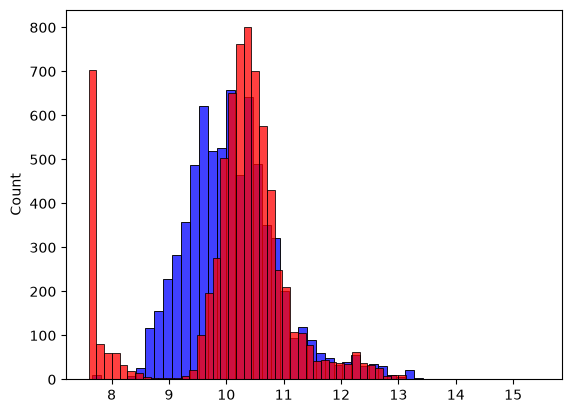

In [680]:
sns.histplot(y_pred, bins=50, color='blue')
sns.histplot(y_train, bins=50, color='red')


In [681]:
def rmse(y_train, y_pred):
    
    error = y_train - y_pred
    se = error ** 2
    mse = np.mean(se)
    rmse = np.sqrt(mse)
    
    return rmse


rmse(y_train, y_pred)

np.float64(0.7385885377864809)

In [682]:
np.expm1(0.73)

np.float64(1.0750806076741226)

## Validating the Model

In [683]:
def prepare_X(df: pd.DataFrame, base: list = ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity']):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [684]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)

y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)


np.float64(0.7241886547922126)

## Simple Feature Engineering


In [685]:
max_year = df_train['year'].max()

def prepare_x(df: pd.DataFrame, base: list = ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity']):
    
    df = df.copy()
    
    df['age'] = max_year - df['year']
    
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [686]:
X_train = prepare_x(df_train)

df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [687]:
X_train[1]

array([170.,   4.,   4.,  38.,  25., 873.,   1.])

In [688]:
X_train = prepare_x(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_x(df_val)

y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.512732555557675)

<Axes: ylabel='Count'>

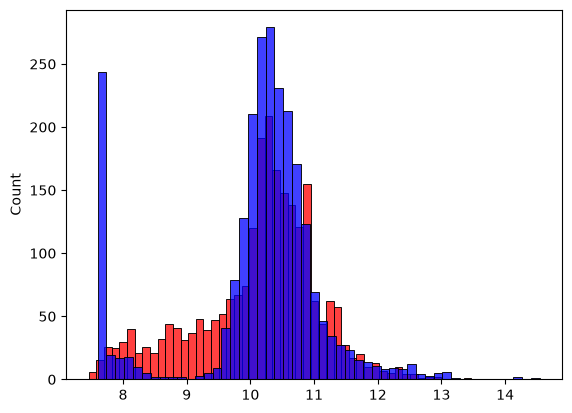

In [689]:
sns.histplot(y_pred, bins=50, color='red')
sns.histplot(y_val, bins=50, color='blue')


### Categorical Variables

#### Strings


In [690]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [691]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type',  'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'
]

categorical = {}

for c in categorical_columns:
    categorical[c] = df_train[c].value_counts().to_dict()
    
categorical

{'make': {'chevrolet': 672,
  'ford': 518,
  'volkswagen': 468,
  'toyota': 450,
  'dodge': 354,
  'nissan': 352,
  'gmc': 326,
  'honda': 282,
  'mazda': 247,
  'cadillac': 237,
  'suzuki': 222,
  'mercedes-benz': 216,
  'infiniti': 196,
  'audi': 189,
  'bmw': 186,
  'hyundai': 180,
  'volvo': 161,
  'subaru': 155,
  'acura': 152,
  'kia': 136,
  'mitsubishi': 127,
  'lexus': 124,
  'buick': 115,
  'chrysler': 114,
  'pontiac': 114,
  'lincoln': 106,
  'oldsmobile': 93,
  'land_rover': 89,
  'porsche': 71,
  'saab': 67,
  'aston_martin': 60,
  'plymouth': 50,
  'bentley': 47,
  'ferrari': 44,
  'fiat': 40,
  'scion': 40,
  'maserati': 38,
  'lamborghini': 30,
  'rolls-royce': 20,
  'lotus': 18,
  'tesla': 12,
  'hummer': 11,
  'maybach': 9,
  'alfa_romeo': 4,
  'mclaren': 3,
  'genesis': 2,
  'spyker': 2,
  'bugatti': 1},
 'model': {'silverado_1500': 97,
  'tundra': 78,
  'f-150': 71,
  'sierra_1500': 58,
  'beetle_convertible': 47,
  'gti': 45,
  'accord': 45,
  'frontier': 44,
  't

In [692]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    new_cols = {}
    for name, values in categorical.items():
        for value in values:
            col_name = '%s_%s' % (name, value)
            new_cols[col_name] = (df[name] == value).astype(int)
            features.append(col_name)

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [693]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)

y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.21204435926090992)

In [694]:
df_full_train = pd.concat([df_train, df_val], axis=0)

In [695]:
df_full_train.reset_index(drop=True, inplace=True)

In [ ]:
X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression(X_full_train, y_full_train, r=0.01)

In [696]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.20711990901313282)

In [697]:
car = df_test.iloc[20].to_dict()
car


{'make': 'toyota',
 'model': 'tacoma',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 236.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'manual',
 'driven_wheels': 'four_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'compact',
 'vehicle_style': 'extended_cab_pickup',
 'highway_mpg': 19,
 'city_mpg': 15,
 'popularity': 2031}

In [698]:
df_small = pd.DataFrame(car, index=[0])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,tacoma,2015,regular_unleaded,236.0,6.0,manual,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,19,15,2031


In [701]:
X_small = prepare_X(df_small)
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred


np.float64(10.177695520728548)

In [702]:
np.expm1(y_pred)

np.float64(26308.76707055576)